# 01 — Exploratory Data Analysis & Business Insights


In [4]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = "../data/"

train = pd.read_csv(f"{DATA_PATH}train.csv", parse_dates=["Date"])
test = pd.read_csv(f"{DATA_PATH}test.csv", parse_dates=["Date"])
features = pd.read_csv(f"{DATA_PATH}features.csv", parse_dates=["Date"], na_values=["NA"])
stores = pd.read_csv(f"{DATA_PATH}stores.csv")

# Standardize holiday flag
for df in [train, test, features]:
    df["IsHoliday"] = df["IsHoliday"].map({"TRUE": True, "FALSE": False, True: True, False: False})

print("Files loaded successfully.")


Files loaded successfully.


## 1. Dataset Overview



In [6]:
%matplotlib inline
datasets = {
    "train": train,
    "test": test,
    "features": features,
    "stores": stores,
}

for name, df in datasets.items():
    print(f"\n{'=' * 50}")
    print(f"{name.upper()} — shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print("\nDtypes:")
    print(df.dtypes)
    missing = df.isna().sum()
    missing = missing[missing > 0]
    if len(missing):
        print("\nMissing values:")
        print(missing)
    else:
        print("\nMissing values: none")



TRAIN — shape: (421570, 5)
Columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']

Dtypes:
Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                 bool
dtype: object

Missing values: none

TEST — shape: (115064, 4)
Columns: ['Store', 'Dept', 'Date', 'IsHoliday']

Dtypes:
Store                 int64
Dept                  int64
Date         datetime64[ns]
IsHoliday              bool
dtype: object

Missing values: none

FEATURES — shape: (8190, 12)
Columns: ['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']

Dtypes:
Store                    int64
Date            datetime64[ns]
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
C

## 2. Weekly Sales Distribution

Understanding the shape of `Weekly_Sales` helps set expectations for forecasting error and outlier handling.


count    421570.00
mean      15981.26
std       22711.18
min       -4988.94
25%        2079.65
50%        7612.03
75%       20205.85
max      693099.36
Name: Weekly_Sales, dtype: float64


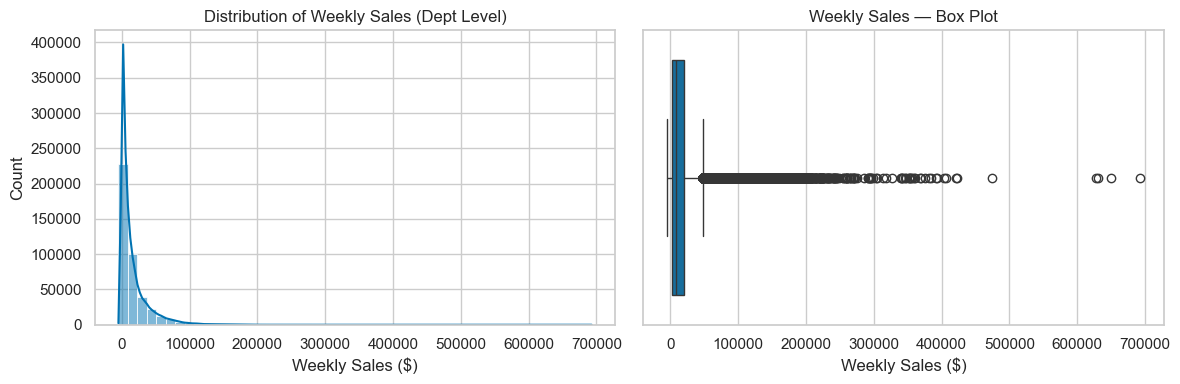

In [3]:
%matplotlib inline
print(train["Weekly_Sales"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(train["Weekly_Sales"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Weekly Sales (Dept Level)")
axes[0].set_xlabel("Weekly Sales ($)")

sns.boxplot(x=train["Weekly_Sales"], ax=axes[1])
axes[1].set_title("Weekly Sales — Box Plot")
axes[1].set_xlabel("Weekly Sales ($)")

plt.tight_layout()
plt.show()


**Business read:** Sales are right-skewed — most departments sell modest weekly volumes, while a smaller share drives very high sales. Planning and staffing models should account for this skew rather than assuming a normal distribution.


## 3. Sales by Store Type

Joining `train` with `stores` lets us compare performance across Walmart formats: **A** (large), **B** (medium), and **C** (small).


      avg_sales  median_sales  dept_weeks
Type                                     
A       20100.0       10105.0      215478
B       12237.0        6188.0      163495
C        9520.0        1150.0       42597


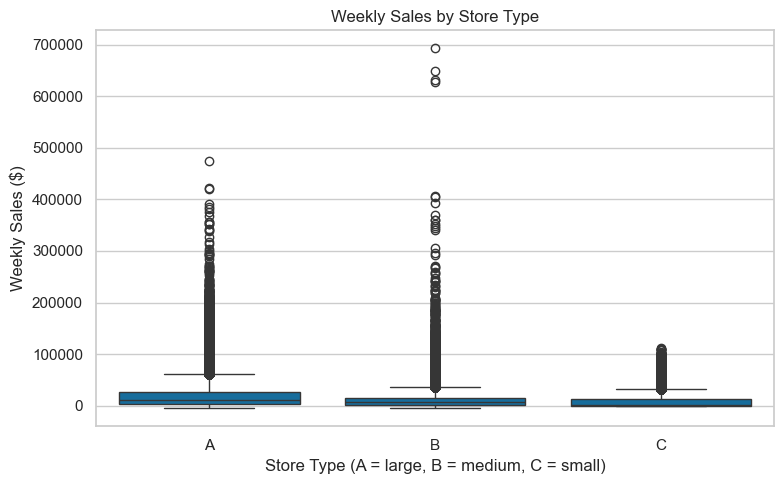

In [7]:
%matplotlib inline
train_stores = train.merge(stores, on="Store")

type_summary = (
    train_stores.groupby("Type")["Weekly_Sales"]
    .agg(avg_sales="mean", median_sales="median", dept_weeks="count")
    .round(0)
)
print(type_summary)

fig, ax = plt.subplots(figsize=(8, 5))
order = ["A", "B", "C"]
sns.boxplot(data=train_stores, x="Type", y="Weekly_Sales", order=order, ax=ax)
ax.set_title("Weekly Sales by Store Type")
ax.set_xlabel("Store Type (A = large, B = medium, C = small)")
ax.set_ylabel("Weekly Sales ($)")
plt.tight_layout()
plt.show()


## 4. Weekly and Monthly Seasonality

Retail sales follow predictable calendar patterns. We aggregate all departments to see company-wide weekly trends and average sales by month.


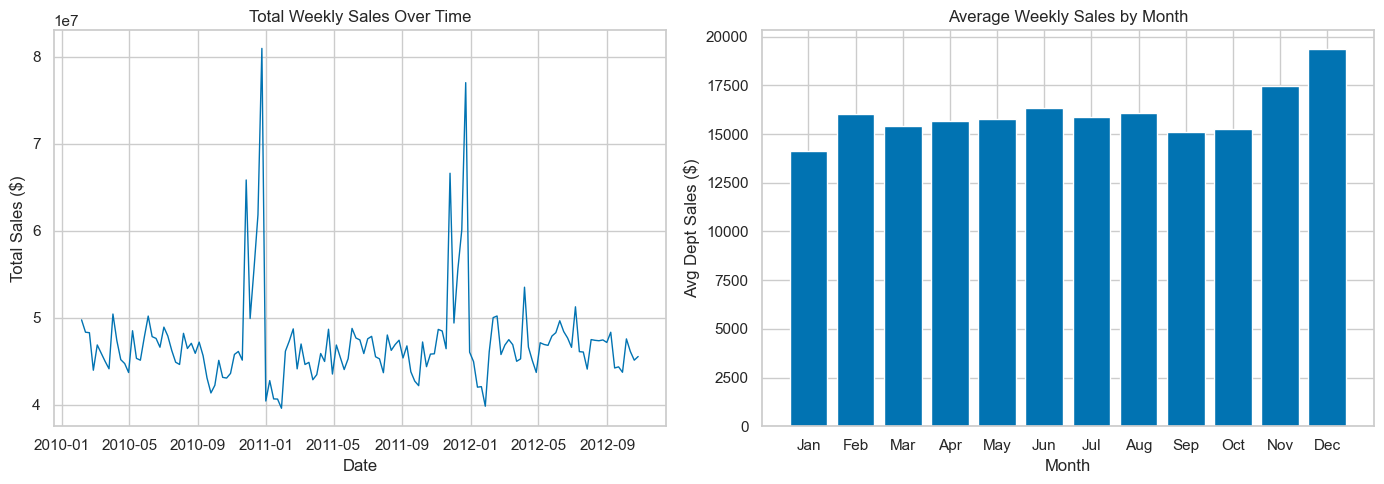

Peak months (avg dept sales):
Date
12    19356.0
11    17491.0
6     16326.0
Name: Weekly_Sales, dtype: float64


In [8]:
%matplotlib inline
weekly_total = train.groupby("Date")["Weekly_Sales"].sum().reset_index(name="total_sales")
weekly_total["month"] = weekly_total["Date"].dt.month
weekly_total["week_of_year"] = weekly_total["Date"].dt.isocalendar().week.astype(int)

monthly_avg = train.groupby(train["Date"].dt.month)["Weekly_Sales"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(weekly_total["Date"], weekly_total["total_sales"], linewidth=1)
axes[0].set_title("Total Weekly Sales Over Time")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Total Sales ($)")

month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
axes[1].bar(range(1, 13), monthly_avg.values, color=sns.color_palette("colorblind")[0])
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_labels)
axes[1].set_title("Average Weekly Sales by Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Avg Dept Sales ($)")

plt.tight_layout()
plt.show()

print("Peak months (avg dept sales):")
print(monthly_avg.sort_values(ascending=False).head(3).round(0))


**Business read:** Sales peak in **November and December** (holiday season) with a secondary lift in mid-year. Inventory, labor, and marketing plans should ramp up ahead of Q4 rather than treating demand as flat across months.


## 5. Holiday vs Non-Holiday Sales

`IsHoliday` flags weeks containing a major US holiday. Comparing average sales reveals whether holidays act as demand drivers.


                     mean  median   count
IsHoliday                                
Non-holiday week  15901.0  7590.0  391909
Holiday week      17036.0  7948.0   29661

Average lift during holiday weeks: 7.1%


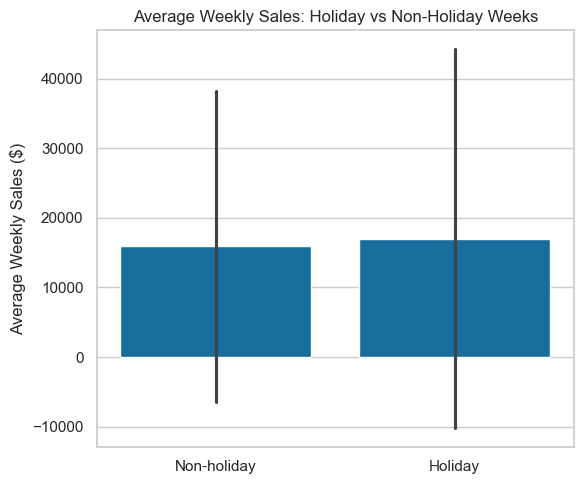

In [9]:
%matplotlib inline
holiday_stats = train.groupby("IsHoliday")["Weekly_Sales"].agg(["mean", "median", "count"]).round(0)
holiday_stats.index = holiday_stats.index.map({True: "Holiday week", False: "Non-holiday week"})
print(holiday_stats)

lift = (holiday_stats.loc["Holiday week", "mean"] / holiday_stats.loc["Non-holiday week", "mean"] - 1) * 100
print(f"\nAverage lift during holiday weeks: {lift:.1f}%")

fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    data=train,
    x="IsHoliday",
    y="Weekly_Sales",
    estimator="mean",
    errorbar="sd",
    order=[False, True],
    ax=ax,
)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Non-holiday", "Holiday"])
ax.set_title("Average Weekly Sales: Holiday vs Non-Holiday Weeks")
ax.set_xlabel("")
ax.set_ylabel("Average Weekly Sales ($)")
plt.tight_layout()
plt.show()


## 6. External Drivers

`features.csv` provides temperature, fuel prices, CPI, unemployment, and promotional markdowns at the **store + week** level. We aggregate train to the same grain and explore relationships.


Missing values in joined analysis frame:
Temperature          0
Fuel_Price           0
CPI                  0
Unemployment         0
MarkDown1         4155
MarkDown2         4798
MarkDown3         4389
MarkDown4         4470
MarkDown5         4140
Total_MarkDown       0
dtype: int64

Correlation with store-week sales:
Total_MarkDown    0.232
Unemployment     -0.106
CPI              -0.073
Temperature      -0.064
Fuel_Price        0.009
Name: Weekly_Sales, dtype: float64


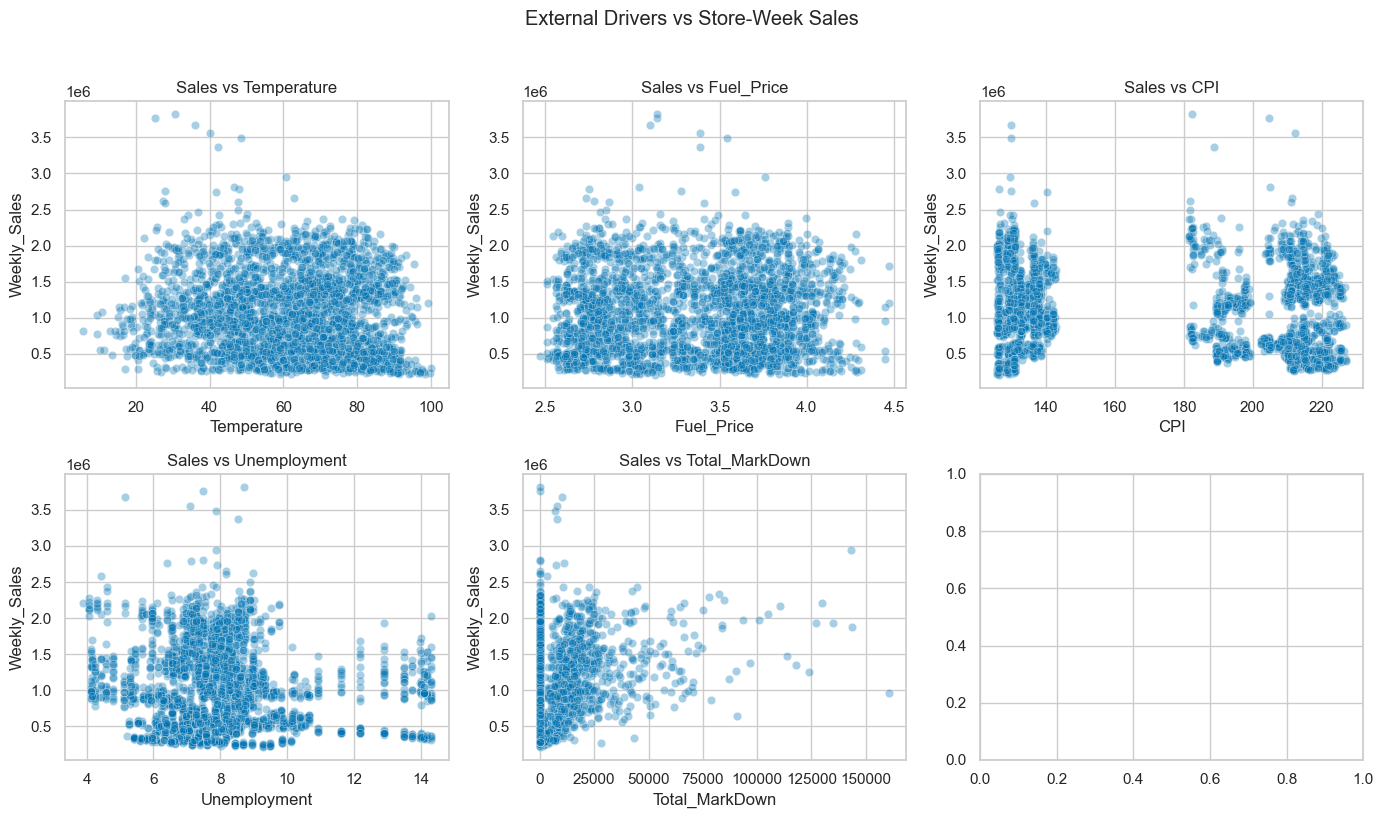

In [10]:
%matplotlib inline
store_week_sales = train.groupby(["Store", "Date"])["Weekly_Sales"].sum().reset_index()
analysis = store_week_sales.merge(features, on=["Store", "Date"], how="left")

driver_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]
markdown_cols = [c for c in features.columns if c.startswith("MarkDown")]
analysis["Total_MarkDown"] = analysis[markdown_cols].sum(axis=1, skipna=True)

print("Missing values in joined analysis frame:")
print(analysis[driver_cols + markdown_cols + ["Total_MarkDown"]].isna().sum())

corr_cols = driver_cols + ["Total_MarkDown", "Weekly_Sales"]
corr = analysis[corr_cols].corr()["Weekly_Sales"].drop("Weekly_Sales").sort_values(key=abs, ascending=False)
print("\nCorrelation with store-week sales:")
print(corr.round(3))

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
plot_cols = driver_cols + ["Total_MarkDown"]
for ax, col in zip(axes.flat, plot_cols):
    sample = analysis[[col, "Weekly_Sales"]].dropna()
    sns.scatterplot(data=sample.sample(min(3000, len(sample)), random_state=42), x=col, y="Weekly_Sales", alpha=0.35, ax=ax)
    ax.set_title(f"Sales vs {col}")

plt.suptitle("External Drivers vs Store-Week Sales", y=1.02)
plt.tight_layout()
plt.show()


## Key Business Insights

1. **Right-skewed sales distribution** — Most departments have moderate weekly sales, but high-volume outliers pull averages up. Use medians or store-type benchmarks alongside means for planning.

2. **Store format matters** — Type A stores outperform B and C on average department sales. Forecasts, targets, and assortment should be segmented by store type rather than applied uniformly.

3. **Strong Q4 seasonality** — November and December are peak months, with elevated demand visible in weekly totals. Inventory and staffing should front-load before the holiday season.

4. **Holiday weeks lift sales ~7%** — Weeks flagged as holidays average higher sales than regular weeks. Operational plans should treat holiday calendars as first-class inputs.

5. **Promotions correlate with higher sales** — Combined markdown spend shows the clearest positive link among external drivers. Promotional calendars are valuable features for forecasting and merchandising analysis.

6. **Economic indicators move sales modestly** — Higher unemployment and CPI associate with slightly lower sales. Macro features may help fine-tune forecasts but are secondary to seasonality and store attributes.
